In [7]:
import pandas as pd


df = pd.read_csv('/home/noda/Projects/raman-spectroscopy/data/combined_raman_data.csv')


In [17]:
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split


# X, y = df[['Brain','Wave_1','Intensity_1','Prominence_1','Wave_2','Intensity_2','Prominence_2','Wave_3','Intensity_3','Prominence_3','Wave_4','Intensity_4','Prominence_4','Wave_5','Intensity_5','Prominence_5','Wave_6','Intensity_6','Prominence_6']], df['Label']
# X, y = df[['Brain','Wave_1','Prominence_1','Wave_2','Prominence_2','Wave_3','Prominence_3','Wave_4','Prominence_4','Wave_5','Prominence_5','Wave_6','Prominence_6']], df['Label']
X, y = df[['Brain','Prominence_1','Prominence_2','Prominence_3','Prominence_4','Prominence_5','Prominence_6']], df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=2000,
    task_type="GPU",
    devices='0',
    loss_function='MultiClass',
    early_stopping_rounds=100,
    verbose=100,
    depth=7,
    random_seed=42,
    learning_rate=0.03,
    subsample=0.6,
    l2_leaf_reg=5,
    bootstrap_type='Bernoulli',
    one_hot_max_size=10
)

model.fit(X_train, y_train, cat_features=['Brain'])

y_pred = model.predict(X_test)

score = f1_score(y_test, y_pred, average='macro')
print(score)

0:	learn: 1.0920701	total: 4.03ms	remaining: 8.05s
100:	learn: 0.6179251	total: 270ms	remaining: 5.07s
200:	learn: 0.4164529	total: 536ms	remaining: 4.8s
300:	learn: 0.3093877	total: 863ms	remaining: 4.87s
400:	learn: 0.2490906	total: 1.32s	remaining: 5.28s
500:	learn: 0.2073053	total: 1.75s	remaining: 5.24s
600:	learn: 0.1765635	total: 2.17s	remaining: 5.05s
700:	learn: 0.1541449	total: 2.59s	remaining: 4.79s
800:	learn: 0.1364690	total: 2.99s	remaining: 4.48s
900:	learn: 0.1219578	total: 3.55s	remaining: 4.33s
1000:	learn: 0.1106217	total: 4.14s	remaining: 4.13s
1100:	learn: 0.1007696	total: 4.55s	remaining: 3.72s
1200:	learn: 0.0922909	total: 4.96s	remaining: 3.3s
1300:	learn: 0.0850564	total: 5.35s	remaining: 2.87s
1400:	learn: 0.0787698	total: 5.77s	remaining: 2.47s
1500:	learn: 0.0736211	total: 6.16s	remaining: 2.05s
1600:	learn: 0.0688837	total: 6.55s	remaining: 1.63s
1700:	learn: 0.0645581	total: 6.94s	remaining: 1.22s
1800:	learn: 0.0606728	total: 7.32s	remaining: 808ms
1900:	

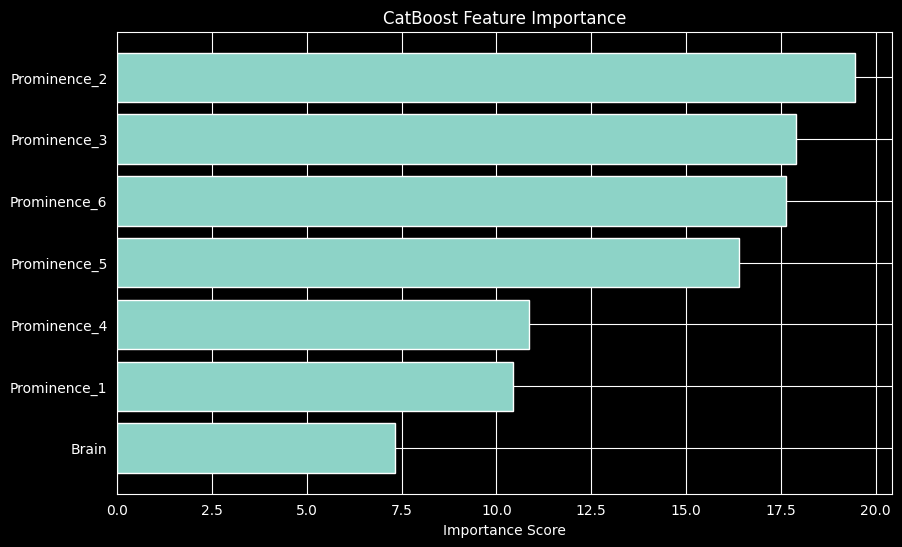

Brain: 7.3158
Prominence_1: 10.4252
Prominence_2: 19.4645
Prominence_3: 17.8967
Prominence_4: 10.8608
Prominence_5: 16.4027
Prominence_6: 17.6342


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Получаем важность признаков
feature_importance = model.get_feature_importance(type='FeatureImportance')
feature_names = X_train.columns

# Сортируем для визуализации
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.show()

# Выведем значения текстом для точности
for name, score in zip(feature_names, feature_importance):
    print(f"{name}: {score:.4f}")

In [14]:
import joblib

joblib.dump(model, '../models/model-catboost(p).joblib')


['../models/model-catboost(p).joblib']